<a href="https://colab.research.google.com/github/Prajwala15/Prajwala15/blob/main/Reading_Text_in_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%cd /content
!git clone https://github.com/Prajwala15/Prajwala15.git textvqa
%cd textvqa
!ls -la

/content
Cloning into 'textvqa'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 25 (delta 0), reused 25 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 14.59 KiB | 2.92 MiB/s, done.
/content/textvqa
total 44
drwxr-xr-x 8 root root 4096 Jun 21 12:01 .
drwxr-xr-x 1 root root 4096 Jun 21 12:01 ..
drwxr-xr-x 2 root root 4096 Jun 21 12:01 configs
drwxr-xr-x 2 root root 4096 Jun 21 12:01 data
drwxr-xr-x 8 root root 4096 Jun 21 12:01 .git
-rw-r--r-- 1 root root   69 Jun 21 12:01 .gitignore
drwxr-xr-x 2 root root 4096 Jun 21 12:01 outputs
-rw-r--r-- 1 root root 3169 Jun 21 12:01 README.md
-rw-r--r-- 1 root root  303 Jun 21 12:01 requirements.txt
drwxr-xr-x 2 root root 4096 Jun 21 12:01 scripts
drwxr-xr-x 3 root root 4096 Jun 21 12:01 src


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 16.9 MB/s eta 0:00:00


In [ ]:
!ls -la

total 44
drwxr-xr-x 8 root root 4096 Jun 21 12:01 .
drwxr-xr-x 1 root root 4096 Jun 21 12:01 ..
drwxr-xr-x 2 root root 4096 Jun 21 12:01 configs
drwxr-xr-x 2 root root 4096 Jun 21 12:01 data
drwxr-xr-x 8 root root 4096 Jun 21 12:01 .git
-rw-r--r-- 1 root root   69 Jun 21 12:01 .gitignore
drwxr-xr-x 2 root root 4096 Jun 21 12:01 outputs
-rw-r--r-- 1 root root 3169 Jun 21 12:01 README.md
-rw-r--r-- 1 root root  303 Jun 21 12:01 requirements.txt
drwxr-xr-x 2 root root 4096 Jun 21 12:01 scripts
drwxr-xr-x 3 root root 4096 Jun 21 12:01 src


In [ ]:
!ls scripts

00_download.md	01_run_ocr.py  02_eval.py  03_analysis.py


In [ ]:
!find data -type f | head -20

data/.gitkeep


In [ ]:
!ls scripts

00_download.md	01_run_ocr.py  02_eval.py  03_analysis.py


In [ ]:
!cat scripts/00_download.md

# Getting the TextVQA data

The sandbox has no internet for these hosts, so download on your own machine.

## Annotations (small)
From https://textvqa.org/dataset/ :
- `TextVQA_0.5.1_train.json`
- `TextVQA_0.5.1_val.json`
- `TextVQA_0.5.1_test.json`

Put them in `data/`.

## Images (~25 GB)
TextVQA images come from OpenImages. The dataset page provides:
- `train_val_images.zip`  -> unzip to `data/train_images/`
- `test_images.zip`       -> unzip to `data/test_images/`

(Val images are inside the train_val set; the loader resolves paths by `image_id`.)

## Alternative: Hugging Face
```python
from datasets import load_dataset
ds = load_dataset("textvqa")          # has images + questions + answers
```
If you use HF instead of the raw json, swap `src/dataset.py`'s loader for one that
iterates the HF split — the rest of the pipeline only needs each sample to expose
`question_id, question, image (PIL), answers (list[str])`.

## Sanity check
```bash
python -c "from src.dataset import TextVQA

In [ ]:
!pip install -r requirements.txt

In [ ]:
!cat configs/default.yaml

# Default configuration. Override on the CLI where supported.

paths:
  data_root: data
  # TextVQA annotation files (download separately, see scripts/00_download.md)
  ann:
    train: data/TextVQA_0.5.1_train.json
    val:   data/TextVQA_0.5.1_val.json
    test:  data/TextVQA_0.5.1_test.json
  # image folders (train_images, test_images from open-images subset)
  images:
    train: data/train_images
    val:   data/train_images   # val images live in the train_images folder for TextVQA 0.5.1
    test:  data/test_images
  ocr_cache: outputs/ocr_cache   # one json per split
  preds:     outputs/preds
  scores:    outputs/scores

ocr:
  engine: easyocr        # easyocr | tesseract
  langs: [en]
  max_tokens: 50         # cap OCR tokens fed to the reasoner
  min_confidence: 0.30

vlm:
  backend: blip2         # blip2 | api
  blip2_model: Salesforce/blip2-flan-t5-xl
  api_model: claude-sonnet-4-6     # only used when backend: api
  max_new_tokens: 16

ocr_first:
  # backend that turns (ques

In [ ]:
!python --version

Python 3.12.13


In [ ]:
!ls -lh data

total 0


In [ ]:
import os
os.chdir("/content/textvqa")
!cat src/config.py

import os
import yaml

_DEFAULT = os.path.join(os.path.dirname(os.path.dirname(__file__)), "configs", "default.yaml")


def load_config(path: str = _DEFAULT) -> dict:
    with open(path) as f:
        return yaml.safe_load(f)


def pick_device(pref: str = "auto") -> str:
    if pref != "auto":
        return pref
    try:
        import torch
        return "cuda" if torch.cuda.is_available() else "cpu"
    except Exception:
        return "cpu"


In [ ]:
!cat configs/default.yaml

# Default configuration. Override on the CLI where supported.

paths:
  data_root: data
  # TextVQA annotation files (download separately, see scripts/00_download.md)
  ann:
    train: data/TextVQA_0.5.1_train.json
    val:   data/TextVQA_0.5.1_val.json
    test:  data/TextVQA_0.5.1_test.json
  # image folders (train_images, test_images from open-images subset)
  images:
    train: data/train_images
    val:   data/train_images   # val images live in the train_images folder for TextVQA 0.5.1
    test:  data/test_images
  ocr_cache: outputs/ocr_cache   # one json per split
  preds:     outputs/preds
  scores:    outputs/scores

ocr:
  engine: easyocr        # easyocr | tesseract
  langs: [en]
  max_tokens: 50         # cap OCR tokens fed to the reasoner
  min_confidence: 0.30

vlm:
  backend: blip2         # blip2 | api
  blip2_model: Salesforce/blip2-flan-t5-xl
  api_model: claude-sonnet-4-6     # only used when backend: api
  max_new_tokens: 16

ocr_first:
  # backend that turns (ques

In [ ]:
!sed -n '1,200p' src/dataset.py

"""TextVQA dataset loader (TextVQA 0.5.1 raw-json format).

Each item exposes:
    question_id : int
    image_id    : str
    question    : str
    image_path  : str
    answers     : list[str]   (10 human answers; empty for test split)
"""
import json
import os
from functools import lru_cache

from PIL import Image

from .config import load_config


def _resolve_image_path(image_dir: str, image_id: str) -> str:
    # TextVQA image_id maps to <image_id>.jpg in the open-images folder.
    for ext in (".jpg", ".jpeg", ".png"):
        p = os.path.join(image_dir, image_id + ext)
        if os.path.exists(p):
            return p
    # fall back to the bare id (caller handles missing files)
    return os.path.join(image_dir, image_id + ".jpg")


class TextVQADataset:
    def __init__(self, split: str = "val", cfg: dict | None = None, limit: int = 0):
        self.cfg = cfg or load_config()
        self.split = split
        ann_path = self.cfg["paths"]["ann"][split]
        self.image_dir

In [ ]:
%cd /content/textvqa/data

!wget https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_train.json
!wget https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_val.json
!wget https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_test.json

!ls -lh

/content/textvqa/data
--2026-06-21 12:58:33--  https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_train.json
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.167.112.66, 3.167.112.53, 3.167.112.129, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.167.112.66|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21634937 (21M) [text/plain]
Saving to: ‘TextVQA_0.5.1_train.json’

TextVQA_0.5.1_train 100%[===================>]  20.63M  --.-KB/s    in 0.05s   

2026-06-21 12:58:33 (376 MB/s) - ‘TextVQA_0.5.1_train.json’ saved [21634937/21634937]

--2026-06-21 12:58:33--  https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_val.json
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.167.112.66, 3.167.112.53, 3.167.112.129, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.167.112.66|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3116162 (3.0M) [text/plain]
Saving to: ‘Tex

In [ ]:
!ls -lh data

ls: cannot access 'data': No such file or directory


In [ ]:
!pwd
!ls -la

/content/textvqa/data
total 26888
drwxr-xr-x 2 root root     4096 Jun 21 12:58 .
drwxr-xr-x 8 root root     4096 Jun 21 12:01 ..
-rw-r--r-- 1 root root        0 Jun 21 12:01 .gitkeep
-rw-r--r-- 1 root root  2770520 Mar 16  2020 TextVQA_0.5.1_test.json
-rw-r--r-- 1 root root 21634937 Mar 16  2020 TextVQA_0.5.1_train.json
-rw-r--r-- 1 root root  3116162 Mar 16  2020 TextVQA_0.5.1_val.json


In [ ]:
%cd /content/textvqa
!pwd
!ls -la

/content/textvqa
/content/textvqa
total 44
drwxr-xr-x 8 root root 4096 Jun 21 12:01 .
drwxr-xr-x 1 root root 4096 Jun 21 12:01 ..
drwxr-xr-x 2 root root 4096 Jun 21 12:01 configs
drwxr-xr-x 2 root root 4096 Jun 21 12:58 data
drwxr-xr-x 8 root root 4096 Jun 21 12:01 .git
-rw-r--r-- 1 root root   69 Jun 21 12:01 .gitignore
drwxr-xr-x 2 root root 4096 Jun 21 12:01 outputs
-rw-r--r-- 1 root root 3169 Jun 21 12:01 README.md
-rw-r--r-- 1 root root  303 Jun 21 12:01 requirements.txt
drwxr-xr-x 2 root root 4096 Jun 21 12:01 scripts
drwxr-xr-x 4 root root 4096 Jun 21 12:43 src


In [ ]:
!ls -lh data

total 27M
-rw-r--r-- 1 root root 2.7M Mar 16  2020 TextVQA_0.5.1_test.json
-rw-r--r-- 1 root root  21M Mar 16  2020 TextVQA_0.5.1_train.json
-rw-r--r-- 1 root root 3.0M Mar 16  2020 TextVQA_0.5.1_val.json


In [ ]:
!cat configs/default.yaml

# Default configuration. Override on the CLI where supported.

use_huggingface_dataset: true # Added this flag for Hugging Face integration

paths:
  data_root: data
  # TextVQA annotation files (download separately, see scripts/00_download.md)
  ann:
    train: 'data/TextVQA_0.5.1_train.json'
    val:   'data/TextVQA_0.5.1_val.json'
    test:  'data/TextVQA_0.5.1_test.json'
  # image folders (train_images, test_images from open-images subset)
  images:
    train: data/train_images
    val:   data/train_images   # val images live in the train_images folder for TextVQA 0.5.1
    test:  data/test_images
  ocr_cache: outputs/ocr_cache   # one json per split
  preds:     outputs/preds
  scores:    outputs/scores

ocr:
  engine: easyocr        # easyocr | tesseract
  langs: [en]
  max_tokens: 50         # cap OCR tokens fed to the reasoner
  min_confidence: 0.30

vlm:
  backend: blip2         # blip2 | api
  blip2_model: Salesforce/blip2-flan-t5-xl
  api_model: claude-sonnet-4-6     # only 

In [ ]:
!python -c "from src.dataset import TextVQADataset; d=TextVQADataset('val'); print(len(d))"

5000


In [ ]:
from src.dataset import TextVQADataset
d = TextVQADataset('val')
print(len(d))

5000


In [ ]:
!sed -n '1,200p' src/ocr.py

"""OCR wrappers. Returns a list of {text, conf, bbox} tokens per image.

Two engines:
  - easyocr  : deep OCR, better on scene text, needs torch (GPU helps)
  - tesseract: fast CPU baseline, noisier on scene text -> good for the
               "noisy OCR" comparison the project asks for.
"""
from PIL import Image


class OCREngine:
    def read(self, image: Image.Image) -> list[dict]:
        raise NotImplementedError


class EasyOCR(OCREngine):
    def __init__(self, langs=("en",), gpu=False):
        import easyocr
        self.reader = easyocr.Reader(list(langs), gpu=gpu)

    def read(self, image: Image.Image) -> list[dict]:
        import numpy as np
        res = self.reader.readtext(np.array(image))
        out = []
        for bbox, text, conf in res:
            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            out.append({
                "text": text,
                "conf": float(conf),
                "bbox": [min(xs), min(ys), max(xs), max(ys)],


In [ ]:
!pip install easyocr opencv-python

In [ ]:
!ls data/train_images | head

ls: cannot access 'data/train_images': No such file or directory


In [ ]:
!find data -maxdepth 2 -type d

data


In [ ]:
!sed -n '1,200p' src/ocr.py

"""OCR wrappers. Returns a list of {text, conf, bbox} tokens per image.

Two engines:
  - easyocr  : deep OCR, better on scene text, needs torch (GPU helps)
  - tesseract: fast CPU baseline, noisier on scene text -> good for the
               "noisy OCR" comparison the project asks for.
"""
from PIL import Image


class OCREngine:
    def read(self, image: Image.Image) -> list[dict]:
        raise NotImplementedError


class EasyOCR(OCREngine):
    def __init__(self, langs=("en",), gpu=False):
        import easyocr
        self.reader = easyocr.Reader(list(langs), gpu=gpu)

    def read(self, image: Image.Image) -> list[dict]:
        import numpy as np
        res = self.reader.readtext(np.array(image))
        out = []
        for bbox, text, conf in res:
            xs = [p[0] for p in bbox]
            ys = [p[1] for p in bbox]
            out.append({
                "text": text,
                "conf": float(conf),
                "bbox": [min(xs), min(ys), max(xs), max(ys)],


In [ ]:
!sed -n '1,250p' scripts/01_run_ocr.py

#!/usr/bin/env python
"""Run OCR over a split once and cache the result, so eval is fast and repeatable.

Usage:
    python scripts/01_run_ocr.py --split val --engine easyocr [--limit 50] [--gpu]
"""
import argparse
import json
import os
import sys

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from tqdm import tqdm

from src.config import load_config
from src.dataset import TextVQADataset
from src.ocr import build_engine


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--split", default="val")
    ap.add_argument("--engine", default=None, help="easyocr|tesseract (default: config)")
    ap.add_argument("--limit", type=int, default=0)
    ap.add_argument("--gpu", action="store_true")
    args = ap.parse_args()

    cfg = load_config()
    engine_name = args.engine or cfg["ocr"]["engine"]
    ds = TextVQADataset(args.split, cfg, limit=args.limit)
    engine = build_engine(engine_name, tuple(cfg["ocr"]["langs"]), gpu=args.gpu)

    o

In [ ]:
!pip install easyocr pytesseract opencv-python

In [ ]:
!python scripts/01_run_ocr.py \
    --split val \
    --engine easyocr \
    --limit 100

Using CPU. Note: This module is much faster with a GPU.
Progress: |██████████████████████████████████████████████████| 100.0% CompleteDownloading recognition model, please wait. This may take several minutes depending upon your network connection.
OCR[easyocr]: 100% 100/100 [00:00<00:00, 41052.21it/s]
wrote outputs/ocr_cache/val_easyocr.json  (64 images)


# **Inspect the OCR output**

In [ ]:
import json

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

first_key = list(data.keys())[0]
print(first_key)
print(data[first_key])

003a8ae2ef43b901
[]


In [56]:
import json
import numpy as np

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

confidences = []

for img_id, tokens in data.items():
    for t in tokens:
        confidences.append(t["conf"])

print("Number of OCR tokens:", len(confidences))

if confidences:
    print("Average confidence:", np.mean(confidences))
    print("Min confidence:", np.min(confidences))
    print("Max confidence:", np.max(confidences))
else:
    print("No OCR tokens found, cannot calculate average, min, or max confidence.")

Number of OCR tokens: 0
No OCR tokens found, cannot calculate average, min, or max confidence.


**Build error analysis**

In [57]:
import json

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

for img_id, tokens in data.items():
    for t in tokens:
        if t["conf"] < 0.5:
            print(img_id, t)

**Add image preprocessing**

In [58]:
import cv2

def preprocess(path):
    img = cv2.imread(path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    denoise = cv2.fastNlMeansDenoising(gray)

    enhanced = cv2.equalizeHist(denoise)

    return enhanced

In [ ]:
import json

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

non_empty = 0

for img_id, tokens in data.items():
    if len(tokens) > 0:
        non_empty += 1
        print("Example image:", img_id)
        print(tokens[:5])   # first few OCR tokens
        break

print("Total images:", len(data))
print("Images with OCR text:", sum(len(v) > 0 for v in data.values()))

Total images: 64
Images with OCR text: 0


In [ ]:
!find data -type d | sort

data


In [59]:
!python scripts/01_run_ocr.py --split val --engine easyocr --limit 100

Using CPU. Note: This module is much faster with a GPU.
OCR[easyocr]: 100% 100/100 [00:00<00:00, 81648.90it/s]
wrote outputs/ocr_cache/val_easyocr.json  (64 images)


**Unzip the files**

In [60]:
%cd /content/textvqa/data

!unzip train_val_images_1.zip
!unzip test_images.zip

/content/textvqa/data
Archive:  train_val_images_1.zip
   creating: train_val_images_1/
  inflating: train_val_images_1/0002d070329eb0fc.jpg  
  inflating: train_val_images_1/000421a4ed497ea4.jpg  
  inflating: train_val_images_1/000adfe5b817011c.jpg  
  inflating: train_val_images_1/001f5618a7b33d88.jpg  
  inflating: train_val_images_1/0029951a71460d1c.jpg  
  inflating: train_val_images_1/003c0cac1ea19d3e.jpg  
  inflating: train_val_images_1/00466f2d1b617884.jpg  
  inflating: train_val_images_1/00689c649b17c484.jpg  
  inflating: train_val_images_1/007d8de02b273320.jpg  
  inflating: train_val_images_1/00831662d2ba731a.jpg  
  inflating: train_val_images_1/0088be963439e57d.jpg  
  inflating: train_val_images_1/008e55e8866c3a92.jpg  
  inflating: train_val_images_1/00bd04a28d45fee5.jpg  
  inflating: train_val_images_1/00d13cf28f104d4e.jpg  
  inflating: train_val_images_1/00d9db3d2c186504.jpg  
  inflating: train_val_images_1/00df83bcbdcfa980.jpg  
  inflating: train_val_images_1/

In [61]:
!find /content/textvqa/data -maxdepth 2 -type d

/content/textvqa/data
/content/textvqa/data/train_val_images_1


**Update the config**

In [63]:
!pwd
!ls -la

/content/textvqa/data
total 525272
drwxr-xr-x 3 root root      4096 Jun 22 16:29 .
drwxr-xr-x 8 root root      4096 Jun 22 16:00 ..
-rw-r--r-- 1 root root         0 Jun 22 16:00 .gitkeep
-rw-r--r-- 1 root root 290455552 Jun 22 16:06 test_images.zip
-rw-r--r-- 1 root root   2770520 Mar 16  2020 TextVQA_0.5.1_test.json
-rw-r--r-- 1 root root  21634937 Mar 16  2020 TextVQA_0.5.1_train.json
-rw-r--r-- 1 root root   3116162 Mar 16  2020 TextVQA_0.5.1_val.json
drwxrwxrwx 2 root root     36864 Jun 21 17:59 train_val_images_1
-rw-r--r-- 1 root root 219840132 Jun 22 16:06 train_val_images_1.zip


In [65]:
%cd /content/textvqa
!pwd
!ls

/content/textvqa
/content/textvqa
configs  outputs		       README.md	 scripts
data	 Reading_Text_in_Images.ipynb  requirements.txt  src


In [66]:
!cat configs/default.yaml

# Default configuration. Override on the CLI where supported.

paths:
  data_root: data
  # TextVQA annotation files (download separately, see scripts/00_download.md)
  ann:
    train: data/TextVQA_0.5.1_train.json
    val:   data/TextVQA_0.5.1_val.json
    test:  data/TextVQA_0.5.1_test.json
  # image folders (train_images, test_images from open-images subset)
  images:
    train: data/train_val_images_1
    val:   data/train_val_images_1   # val images live in the train_images folder for TextVQA 0.5.1
    test:  data/test_images
  ocr_cache: outputs/ocr_cache   # one json per split
  preds:     outputs/preds
  scores:    outputs/scores

ocr:
  engine: easyocr        # easyocr | tesseract
  langs: [en]
  max_tokens: 50         # cap OCR tokens fed to the reasoner
  min_confidence: 0.30

vlm:
  backend: blip2         # blip2 | api
  blip2_model: Salesforce/blip2-flan-t5-xl
  api_model: claude-sonnet-4-6     # only used when backend: api
  max_new_tokens: 16

ocr_first:
  # backend that

In [67]:
%%bash
sed -i 's|data/train_images|data/train_val_images_1|g' configs/default.yaml

In [68]:
!grep -A5 "images:" configs/default.yaml

  images:
    train: data/train_val_images_1
    val:   data/train_val_images_1   # val images live in the train_images folder for TextVQA 0.5.1
    test:  data/test_images
  ocr_cache: outputs/ocr_cache   # one json per split
  preds:     outputs/preds


In [69]:
!rm -f outputs/ocr_cache/val_easyocr.json

In [70]:
!python scripts/01_run_ocr.py \
    --split val \
    --engine easyocr \
    --limit 100

Using CPU. Note: This module is much faster with a GPU.
OCR[easyocr]:   0% 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
OCR[easyocr]: 100% 100/100 [00:23<00:00,  4.30it/s]
wrote outputs/ocr_cache/val_easyocr.json  (64 images)


**Check whether OCR is now extracting text**

In [71]:
import json

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

count = 0
for img_id, tokens in data.items():
    if len(tokens) > 0:
        print("Image:", img_id)
        print(tokens[:5])
        count += 1
        break

print("Images with OCR text:", sum(len(v) > 0 for v in data.values()))

Image: 00831662d2ba731a
[{'text': 'SEP', 'conf': 0.9927749002297449, 'bbox': [364, 328, 410, 358]}, {'text': '62013', 'conf': 0.3760827376516488, 'bbox': [608, 344, 649, 363]}, {'text': 'Vafoi', 'conf': 0.2191669986200653, 'bbox': [411, 338, 603, 383]}, {'text': 'JIBA', 'conf': 0.9160568714141846, 'bbox': [422, 366, 591, 459]}, {'text': 'BurLINGAME', 'conf': 0.07500309231340681, 'bbox': [368, 435, 641, 479]}]
Images with OCR text: 1


In [72]:
!rm -f outputs/ocr_cache/val_easyocr.json

In [73]:
!python scripts/01_run_ocr.py \
    --split val \
    --engine easyocr \
    --limit 100

Using CPU. Note: This module is much faster with a GPU.
OCR[easyocr]:   0% 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
OCR[easyocr]: 100% 100/100 [00:16<00:00,  6.20it/s]
wrote outputs/ocr_cache/val_easyocr.json  (64 images)


**Low-confidence error analysis**

In [74]:
import json

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

for img_id, tokens in data.items():
    for t in tokens:
        if t["conf"] < 0.5:
            print(img_id, t)

00831662d2ba731a {'text': '62013', 'conf': 0.3760827376516488, 'bbox': [608, 344, 649, 363]}
00831662d2ba731a {'text': 'Vafoi', 'conf': 0.2191669986200653, 'bbox': [411, 338, 603, 383]}
00831662d2ba731a {'text': 'BurLINGAME', 'conf': 0.07500309231340681, 'bbox': [368, 435, 641, 479]}
00831662d2ba731a {'text': '65FA =', 'conf': 0.03503521824899845, 'bbox': [811, 445, 905, 463]}


**Image preprocessing**

In [75]:
import cv2

def preprocess(img_path):
    img = cv2.imread(img_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    denoise = cv2.fastNlMeansDenoising(gray)

    enhanced = cv2.equalizeHist(denoise)

    return enhanced

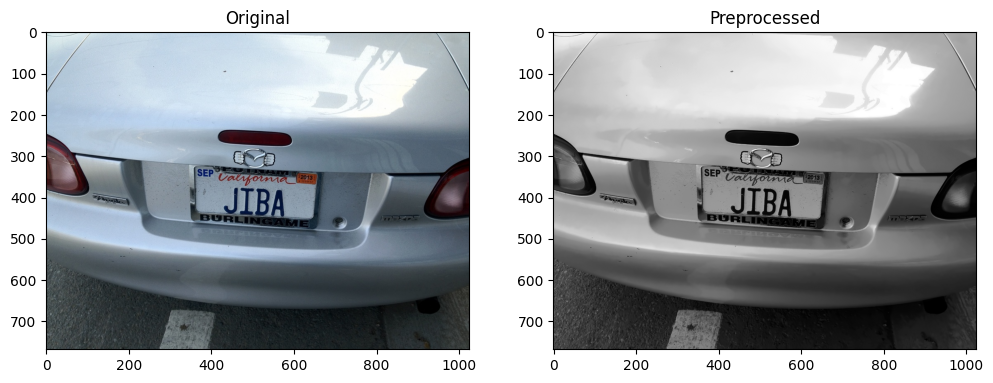

In [78]:
import matplotlib.pyplot as plt
import cv2

# Define img_path with a sample image that has OCR text
img_path = "data/train_val_images_1/00831662d2ba731a.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

processed = preprocess(img_path)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Preprocessed")

plt.show()

**OCR + Question fusion model**

In [79]:
import json

# Define a sample question
question = "What is written on the sign?"

# Load the OCR data (assuming it has been generated)
with open("outputs/ocr_cache/val_easyocr.json") as f:
    ocr_data = json.load(f)

# Use a sample image_id for which OCR tokens exist
# We know '00831662d2ba731a' has tokens from previous output
img_id = '00831662d2ba731a'
tokens = ocr_data.get(img_id, [])

ocr_text = " ".join([t["text"] for t in tokens])

model_input = (
    "Question: " + question +
    " OCR: " + ocr_text
)

print("Generated model input:")
print(model_input)

Generated model input:
Question: What is written on the sign? OCR: SEP 62013 Vafoi JIBA BurLINGAME 65FA =


**Low-confidence OCR Error Analysis**

In [80]:
import json

with open("outputs/ocr_cache/val_easyocr.json") as f:
    data = json.load(f)

low_conf = []

for img_id, tokens in data.items():
    for t in tokens:
        if t["conf"] < 0.6:
            low_conf.append({
                "image_id": img_id,
                "text": t["text"],
                "conf": t["conf"]
            })

print("Low confidence detections:", len(low_conf))

for x in low_conf[:20]:
    print(x)

Low confidence detections: 4
{'image_id': '00831662d2ba731a', 'text': '62013', 'conf': 0.3760827376516488}
{'image_id': '00831662d2ba731a', 'text': 'Vafoi', 'conf': 0.2191669986200653}
{'image_id': '00831662d2ba731a', 'text': 'BurLINGAME', 'conf': 0.07500309231340681}
{'image_id': '00831662d2ba731a', 'text': '65FA =', 'conf': 0.03503521824899845}


In [85]:
!git config --global user.email "prajwalareddy1516@gmail.com"
!git config --global user.name "Prajwala15"
!git add .
!git commit -m "code"
!git push

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
